# Theta-cycle detection tutorial

Detect theta cycles from one LFP channel and inspect the saved CellExplorer-compatible events. The session path matches `lfp_loader_tutorial.ipynb`.


In [1]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import matplotlib.pyplot as plt
import numpy as np

import neuro_py as npy

npy.plotting.set_plotting_defaults()


## 1. Set the session path

Set `basepath` to the same session used in the LFP loader tutorial. It must contain the LFP recording, XML metadata, and channel annotations used to choose a theta channel.


In [2]:
basepath = r"U:\data\hpc_ctx_project\HP18\hp18_day85_20250713"

## 2. Load one theta channel

`LFPLoader` accesses a single channel without loading the full recording. The channel is selected from the `CA1so` annotation, matching the detector's default preference.


In [3]:
brain_regions = npy.io.load_brain_regions(basepath, out_format="DataFrame")
theta_channel = int(brain_regions.query("region == 'CA1so'").channels.iloc[0])
theta_lfp = npy.io.LFPLoader(basepath, channels=theta_channel, ext="lfp")
times = theta_lfp.abscissa_vals
signal = theta_lfp.data[0]
print(f"theta channel: {theta_channel}; sampling rate: {theta_lfp.fs} Hz")

theta channel: 175; sampling rate: 1250 Hz


## 3. Inspect the raw trace

A short raw window verifies that the selected channel contains an oscillatory signal before running the full-session detector.


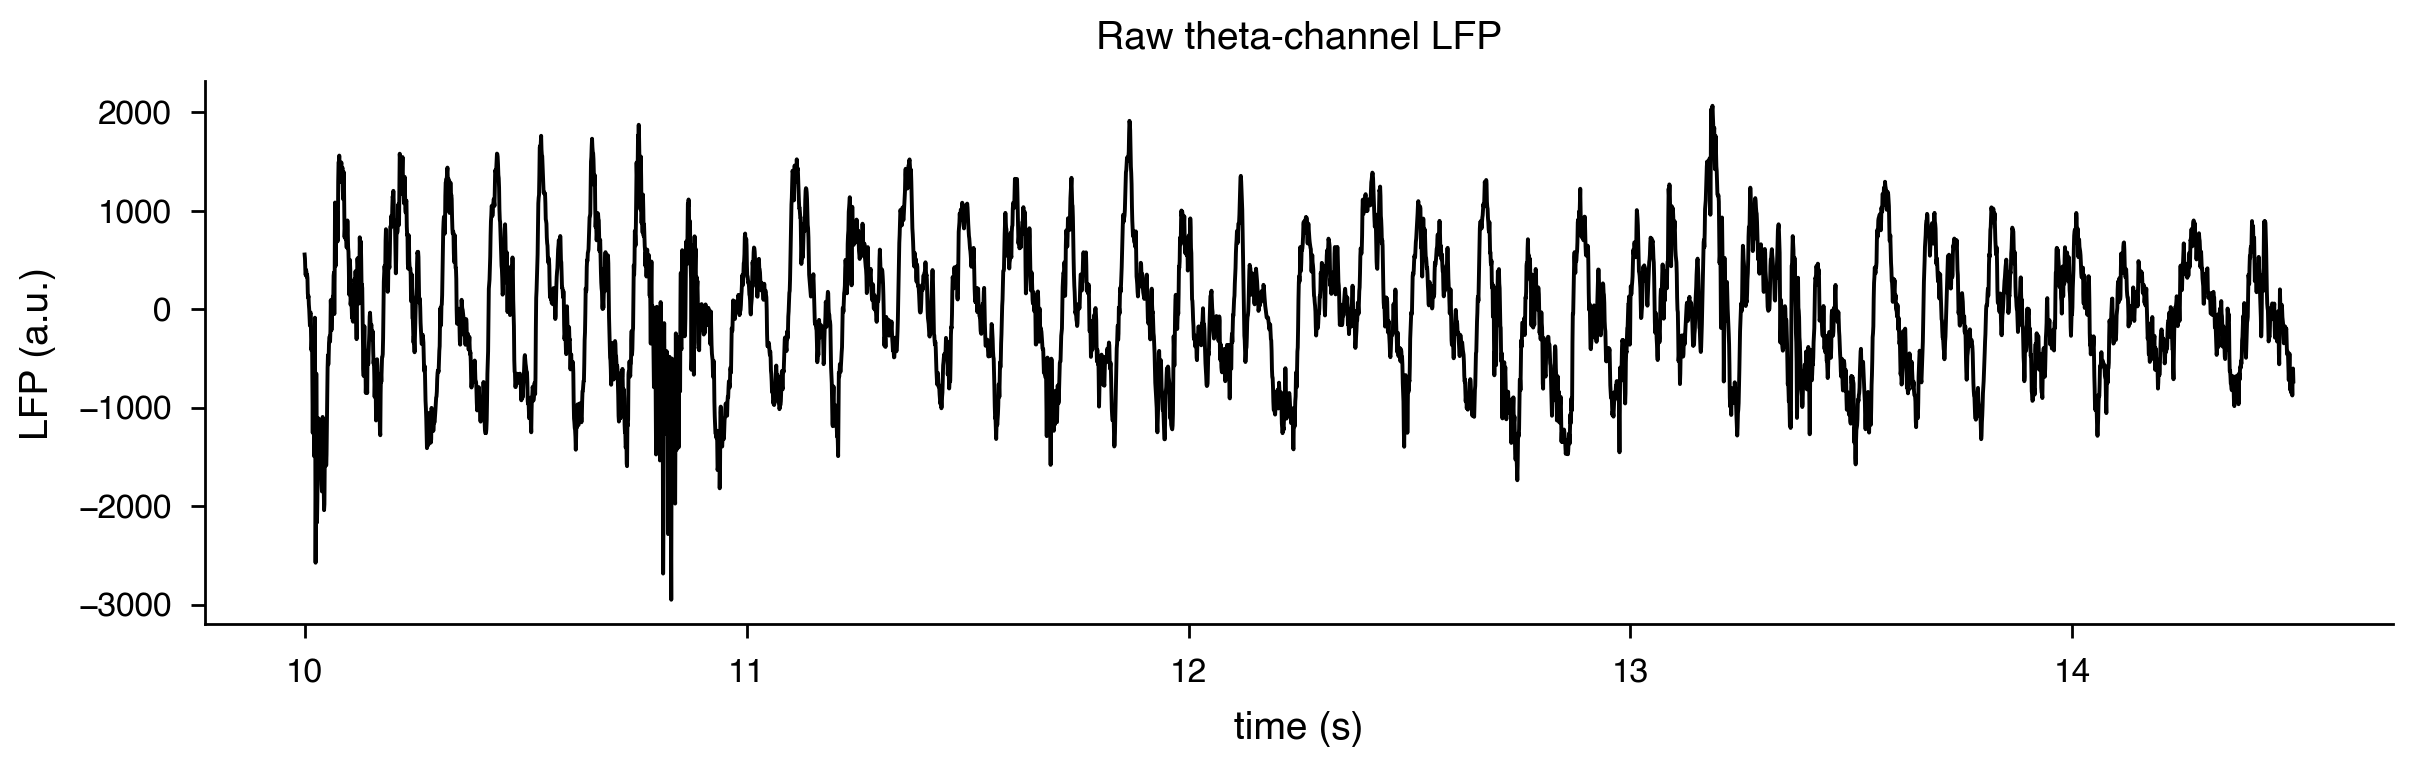

In [4]:
window_start = float(times[0] + 10.0)
window_stop = window_start + 4.5
window = (times >= window_start) & (times <= window_stop)

fig, ax = plt.subplots(
    figsize=npy.plotting.set_size(width="nature_double", ratio=0.25), dpi=200
)
ax.plot(times[window], signal[window], color="black", lw=0.7)
ax.set(xlabel="time (s)", ylabel="LFP (a.u.)", title="Raw theta-channel LFP")
plt.show()

## 4. Detect and reload theta cycles

`get_theta_cycles` detects cycles over the session and writes the standard `.thetacycles.events.mat` file. Reloading through `npy.io` gives the cycle boundaries and trough times used below.


In [5]:
npy.lfp.get_theta_cycles(basepath, ch=theta_channel)
theta_cycles = npy.io.load_theta_cycles(basepath)
theta_cycles.head()

,start,stop,duration,center,trough,theta_channel
0,0.2008,0.3464,0.1456,0.2736,0.2856,175
1,0.3464,0.5240,0.1776,0.4352,0.4536,175
2,0.5240,0.6920,0.1680,0.6080,0.6536,175
3,1.6560,1.8264,0.1704,1.7412,1.7400,175
4,1.8264,1.9336,0.1072,1.8800,1.8704,175


## 5. Overlay detected cycle boundaries and troughs

The boundary lines and trough markers should align with the visible theta rhythm in the raw trace. This is a direct visual check of the detector output.


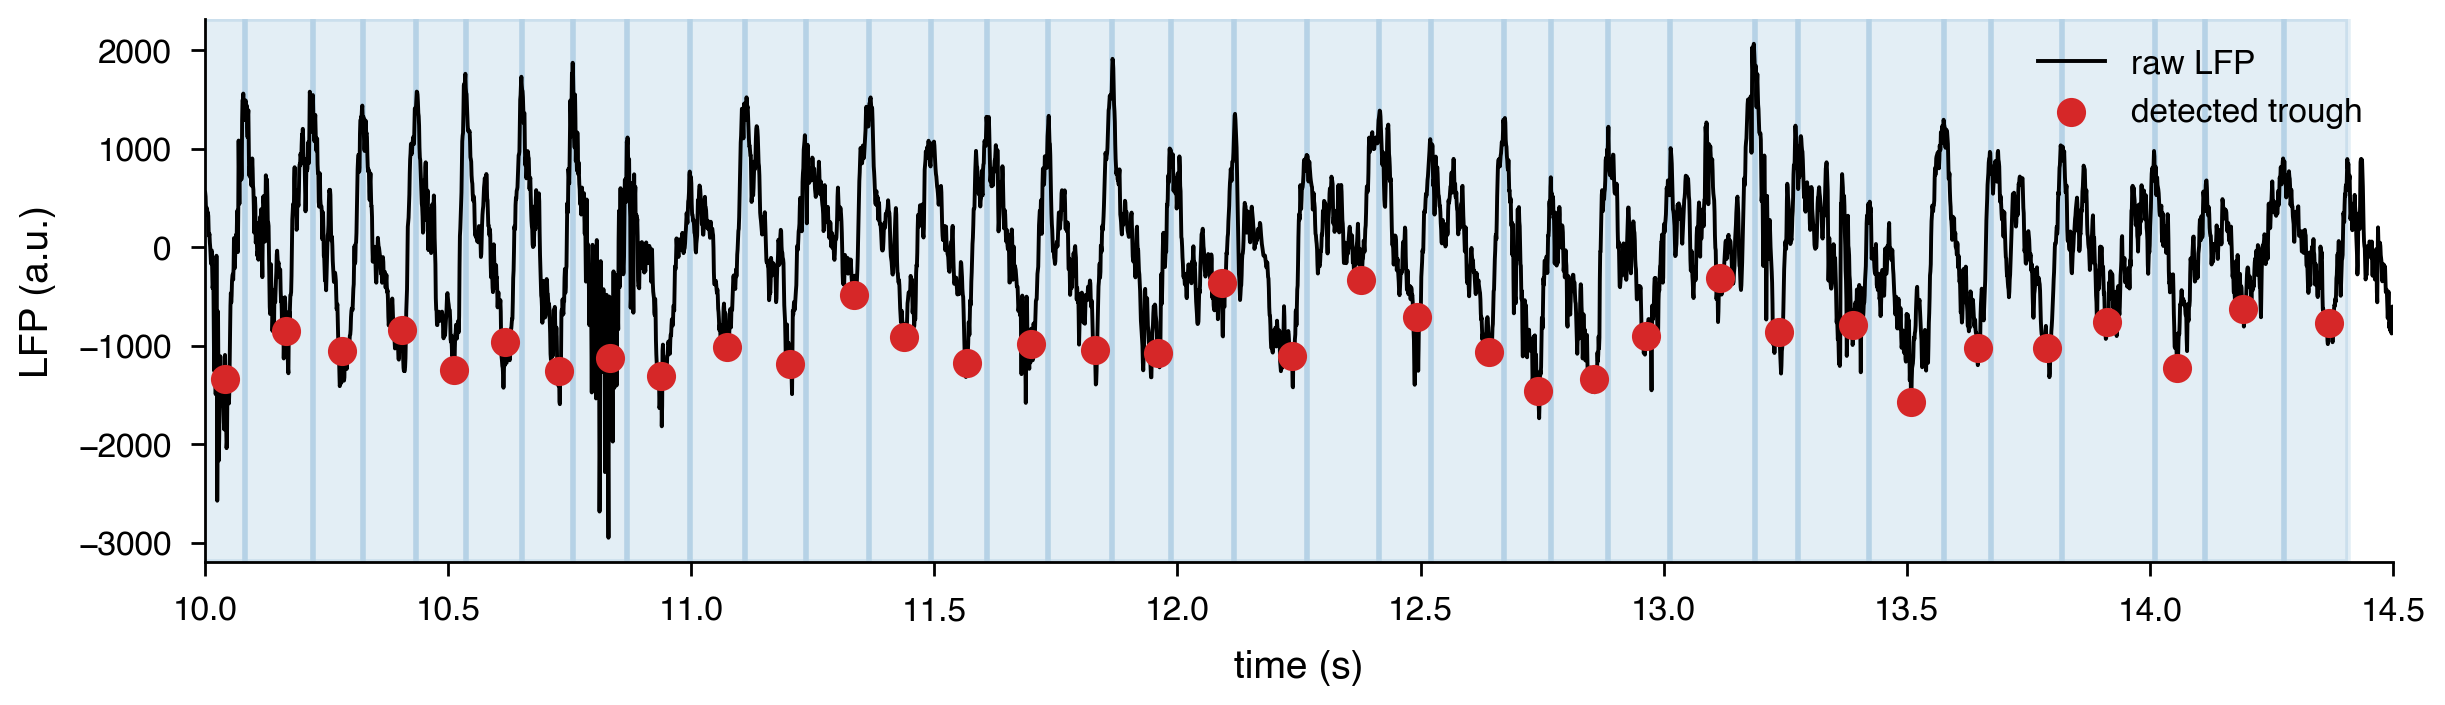

In [6]:
cycles_in_window = theta_cycles.query("start <= @window_stop and stop >= @window_start")

fig, ax = plt.subplots(
    figsize=npy.plotting.set_size(width="nature_double", ratio=0.25), dpi=200
)
ax.plot(times[window], signal[window], color="black", lw=0.7, label="raw LFP")
for start, stop in cycles_in_window[["start", "stop"]].to_numpy():
    ax.axvspan(start, stop, color="tab:blue", alpha=0.12)
ax.scatter(
    cycles_in_window.trough,
    np.interp(cycles_in_window.trough, times, signal),
    color="tab:red",
    s=18,
    zorder=3,
    label="detected trough",
)
ax.set(xlim=(window_start, window_stop), xlabel="time (s)", ylabel="LFP (a.u.)")
ax.legend(frameon=False)
plt.show()